Epoch 001/100 | train_loss=0.00146437
Epoch 002/100 | train_loss=0.00029857
Epoch 003/100 | train_loss=0.00026495
Epoch 004/100 | train_loss=0.00025458
Epoch 005/100 | train_loss=0.00025085
Epoch 006/100 | train_loss=0.00025272

Stopping early after epoch 6: last 3 train losses are all within 2.0% of each other.

=== FINAL TEST METRICS ===
RMSE (m):   3012.9451
MAE  (m):   1344.9403
Median (m): 629.0491
P95   (m):  5323.1270

=== RESULTS PREVIEW ===
   idx  row_id       MMSI     voyage_id                TIME  delta_t  \
0    0       8  209425000  10_209425000 2024-03-03 11:30:00    300.0   
1    1       9  209425000  10_209425000 2024-03-03 11:35:00    300.0   
2    2      10  209425000  10_209425000 2024-03-03 11:40:00    300.0   
3    3      11  209425000  10_209425000 2024-03-03 11:45:00    300.0   
4    4      12  209425000  10_209425000 2024-03-03 11:50:00    300.0   

   delta_t_from_last_x   last_lat   last_lon  pred_dlat  pred_dlon  true_dlat  \
0                300.0  22.26390

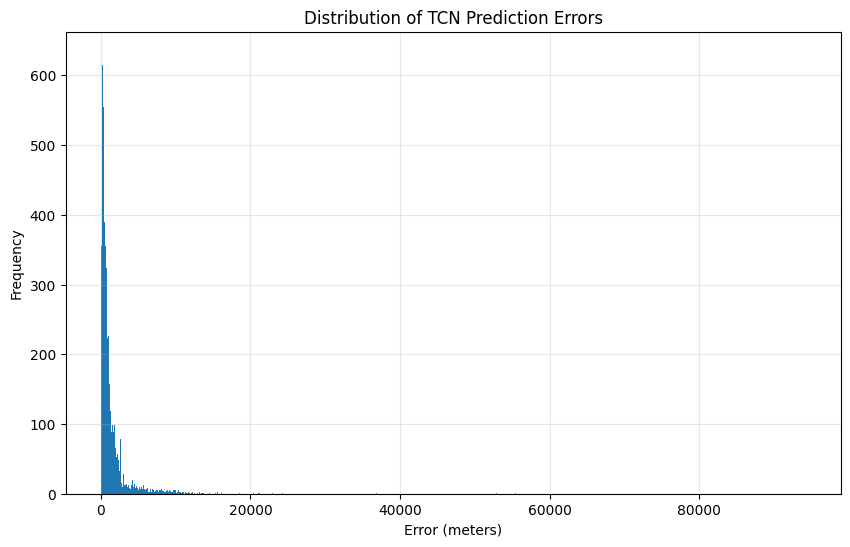


=== ERROR DISTRIBUTION SUMMARY ===
Q1: 292.35
Median: 629.05
Q3: 1399.79
IQR: 1107.43
Lower bound: -1368.80
Upper bound: 3060.94
Number of outliers: 599
Percent of outliers: 9.08%


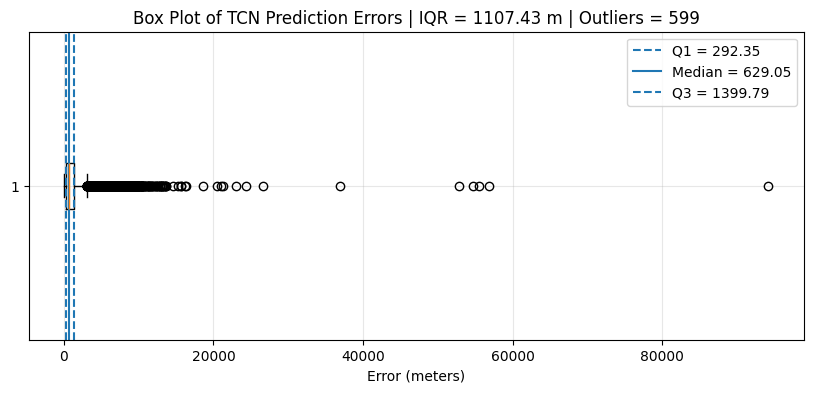

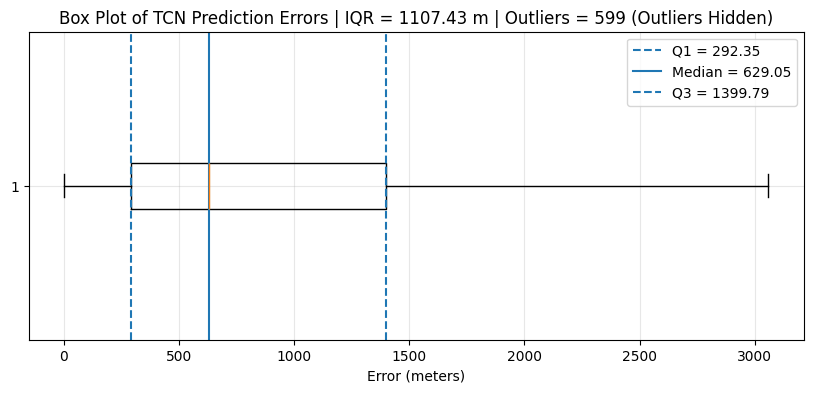


=== LARGE-ERROR VOYAGE MAPS ===
Bad predictions found: 12
Saved: tcn_outlier_maps/outlier_01_mmsi_538010031_voyage_4_538010031.html
Saved: tcn_outlier_maps/outlier_02_mmsi_305350000_voyage_11_305350000.html
Saved: tcn_outlier_maps/outlier_03_mmsi_636024686_voyage_1_636024686.html
Saved: tcn_outlier_maps/outlier_04_mmsi_305350000_voyage_11_305350000.html
Saved: tcn_outlier_maps/outlier_05_mmsi_563458000_voyage_2_563458000.html
Saved: tcn_outlier_maps/outlier_06_mmsi_636024686_voyage_1_636024686.html
Saved: tcn_outlier_maps/outlier_07_mmsi_255802560_voyage_1_255802560.html
Saved: tcn_outlier_maps/outlier_08_mmsi_255802970_voyage_2_255802970.html
Saved: tcn_outlier_maps/outlier_09_mmsi_563458000_voyage_3_563458000.html
Saved: tcn_outlier_maps/outlier_10_mmsi_636024686_voyage_1_636024686.html
Saved: tcn_outlier_maps/outlier_11_mmsi_538001682_voyage_4_538001682.html
Saved: tcn_outlier_maps/outlier_12_mmsi_636024686_voyage_1_636024686.html


In [14]:
from __future__ import annotations

import json
import random
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path
from typing import List

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset


# ============================================================
# CONFIG
# ============================================================

@dataclass
class Config:
    # ----------------------------
    # Project paths (relative to capstone/)
    # ----------------------------
    train_path: str = "data/raw/train_data.csv"
    test_path: str = "data/raw/test_data.csv"
    experiments_dir: str = "experiments"

    # ----------------------------
    # Data / model setup
    # ----------------------------
    seq_len: int = 19
    batch_size: int = 32
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    dropout: float = 0.25
    kernel_size: int = 3

    tcn_channels: tuple = (32, 64, 64)
    dilations: tuple = (1, 2, 4)

    # ----------------------------
    # Early stopping
    # ----------------------------
    max_epochs: int = 100
    min_epochs: int = 10
    loss_stability_threshold: float = 0.02

    # ----------------------------
    # Runtime
    # ----------------------------
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # ----------------------------
    # Core columns
    # ----------------------------
    track_id_col: str = "voyage_id"
    vessel_id_col: str = "MMSI"
    time_col: str = "TIME"
    lat_col: str = "LAT"
    lon_col: str = "LON"
    speed_col: str = "SPEED"
    cog_col: str = "COG"
    heading_col: str = "HEADING"
    dt_col: str = "dt"

    earth_radius_m: float = 6_371_000.0

    # ----------------------------
    # Reporting / artifacts
    # ----------------------------
    histogram_bins: int = 250
    large_error_threshold: float = 20000.0
    save_outlier_maps: bool = True


# optional default config for one-off manual runs
CFG = Config()


# ============================================================
# LOGGING
# ============================================================

class RunLogger:
    def __init__(self, log_path: Path):
        self.log_path = log_path
        self.log_path.parent.mkdir(parents=True, exist_ok=True)
        self.f = open(self.log_path, "w", encoding="utf-8")

    def log(self, message: str = ""):
        print(message)
        self.f.write(message + "\n")
        self.f.flush()

    def close(self):
        self.f.close()


# ============================================================
# BASIC UTILITIES
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def format_lr_for_name(x: float) -> str:
    return f"{x:.0e}".replace("+0", "").replace("+", "")


def make_run_name(cfg: Config) -> str:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ch = "-".join(str(x) for x in cfg.tcn_channels)
    dil = "-".join(str(x) for x in cfg.dilations)
    return (
        f"{timestamp}"
        f"_seq{cfg.seq_len}"
        f"_bs{cfg.batch_size}"
        f"_lr{format_lr_for_name(cfg.learning_rate)}"
        f"_do{cfg.dropout}"
        f"_ks{cfg.kernel_size}"
        f"_ch{ch}"
        f"_dil{dil}"
    )


def config_to_jsonable_dict(cfg: Config) -> dict:
    d = asdict(cfg)
    d["tcn_channels"] = list(cfg.tcn_channels)
    d["dilations"] = list(cfg.dilations)
    return d


def append_experiment_summary(summary_row: dict, experiments_dir: Path):
    summary_path = experiments_dir / "experiment_summary.csv"
    row_df = pd.DataFrame([summary_row])

    if summary_path.exists():
        existing = pd.read_csv(summary_path)
        combined = pd.concat([existing, row_df], ignore_index=True)
    else:
        combined = row_df

    combined.to_csv(summary_path, index=False)


# ============================================================
# DATA LOADING / PREP
# ============================================================

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["TIME"] = pd.to_datetime(df["TIME"], errors="coerce")

    numeric_cols = ["LAT", "LON", "SPEED", "COG", "HEADING", "dt"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["dt"] = df["dt"].fillna(0.0)
    df.loc[df["dt"] < 0, "dt"] = 0.0
    df.loc[df["dt"] > 1800, "dt"] = 0.0

    df["HEADING"] = df["HEADING"].fillna(df["COG"])

    required = [
        "voyage_id", "MMSI", "row_id", "num_pings",
        "TIME", "LAT", "LON", "SPEED", "COG", "HEADING", "dt"
    ]
    df = df.dropna(subset=required).copy()

    df["MMSI"] = df["MMSI"].astype(str)
    df["voyage_id"] = df["voyage_id"].astype(str)
    df["row_id"] = df["row_id"].astype(str)

    df = df.sort_values(["voyage_id", "TIME"]).reset_index(drop=True)
    return df


def add_features_and_targets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["COG_rad"] = np.deg2rad(df["COG"] % 360.0)
    df["COG_cos"] = np.cos(df["COG_rad"])
    df["COG_sin"] = np.sin(df["COG_rad"])

    df["HEADING_rad"] = np.deg2rad(df["HEADING"] % 360.0)
    df["HEADING_cos"] = np.cos(df["HEADING_rad"])
    df["HEADING_sin"] = np.sin(df["HEADING_rad"])

    df["next_lat"] = df.groupby("voyage_id")["LAT"].shift(-1)
    df["next_lon"] = df.groupby("voyage_id")["LON"].shift(-1)

    df["dlat"] = df["next_lat"] - df["LAT"]
    df["dlon"] = df["next_lon"] - df["LON"]

    df = df.dropna(subset=["dlat", "dlon"]).reset_index(drop=True)
    return df


FEATURE_COLS = [
    "LAT", "LON", "SPEED", "dt",
    "COG_cos", "COG_sin", "HEADING_cos", "HEADING_sin"
]

TARGET_COLS = ["dlat", "dlon"]


def build_sequences(df: pd.DataFrame, cfg: Config):
    X_list, y_list, last_pos_list, meta_rows = [], [], [], []

    for _, group in df.groupby(cfg.track_id_col, sort=False):
        group = group.sort_values(cfg.time_col).reset_index(drop=True)

        if len(group) <= cfg.seq_len:
            continue

        X_vals = group[FEATURE_COLS].to_numpy(dtype=np.float32)
        y_vals = group[TARGET_COLS].to_numpy(dtype=np.float32)
        latlon_vals = group[[cfg.lat_col, cfg.lon_col]].to_numpy(dtype=np.float32)

        for i in range(len(group) - cfg.seq_len):
            last_idx = i + cfg.seq_len - 1
            pred_idx = i + cfg.seq_len

            X_seq = X_vals[i:i + cfg.seq_len]
            y_next = y_vals[last_idx]
            last_pos = latlon_vals[last_idx]

            X_list.append(X_seq)
            y_list.append(y_next)
            last_pos_list.append(last_pos)

            meta_rows.append({
                "row_id": group.loc[pred_idx, "row_id"],
                "MMSI": group.loc[pred_idx, cfg.vessel_id_col],
                "voyage_id": group.loc[pred_idx, cfg.track_id_col],
                "TIME": group.loc[last_idx, cfg.time_col],
                "delta_t": float(group.loc[last_idx, cfg.dt_col]),
                "num_pings": group.loc[pred_idx, "num_pings"],
            })

    X = np.stack(X_list).astype(np.float32)
    y = np.stack(y_list).astype(np.float32)
    last_pos = np.stack(last_pos_list).astype(np.float32)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, last_pos, meta_df


def scale_X_train_test(X_train: np.ndarray, X_test: np.ndarray):
    n_train, seq_len, n_features = X_train.shape
    n_test = X_test.shape[0]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n_train * seq_len, n_features))

    X_train_scaled = scaler.transform(
        X_train.reshape(n_train * seq_len, n_features)
    ).reshape(n_train, seq_len, n_features)

    X_test_scaled = scaler.transform(
        X_test.reshape(n_test * seq_len, n_features)
    ).reshape(n_test, seq_len, n_features)

    return X_train_scaled.astype(np.float32), X_test_scaled.astype(np.float32), scaler


# ============================================================
# DATASET
# ============================================================

class SequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================
# MODEL
# ============================================================

class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous() if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ELU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ELU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.final_act = nn.ELU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.final_act(out + res)


class TCN(nn.Module):
    def __init__(self, input_dim, output_dim, channels, kernel_size, dilations, dropout):
        super().__init__()

        layers = []
        in_ch = input_dim
        for out_ch, dilation in zip(channels, dilations):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(in_ch, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        z = self.tcn(x)
        z_last = z[:, :, -1]
        return self.fc(z_last)


# ============================================================
# TRAIN / PREDICT
# ============================================================

def within_2_percent(a, b, threshold=0.02):
    return abs(a - b) / ((a + b) / 2) <= threshold


def train_model(model, train_loader, cfg: Config, logger: RunLogger):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay
    )
    loss_fn = nn.MSELoss()

    train_losses = []
    stopped_early = False

    for epoch in range(cfg.max_epochs):
        model.train()
        total_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(cfg.device)
            y_batch = y_batch.to(cfg.device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        logger.log(f"Epoch {epoch+1:03d}/{cfg.max_epochs} | train_loss={avg_loss:.8f}")

        if len(train_losses) >= 3 and (epoch + 1) >= cfg.min_epochs:
            l1, l2, l3 = train_losses[-3:]

            cond_12 = within_2_percent(l1, l2, cfg.loss_stability_threshold)
            cond_23 = within_2_percent(l2, l3, cfg.loss_stability_threshold)
            cond_13 = within_2_percent(l1, l3, cfg.loss_stability_threshold)

            if cond_12 and cond_23 and cond_13:
                logger.log(
                    f"\nStopping early after epoch {epoch+1}: "
                    f"last 3 train losses are all within "
                    f"{cfg.loss_stability_threshold*100:.1f}% of each other."
                )
                stopped_early = True
                break

    return {
        "train_losses": train_losses,
        "epochs_trained": len(train_losses),
        "stopped_early": stopped_early,
        "final_train_loss": float(train_losses[-1]),
    }


def predict_model(model, loader, cfg: Config):
    model.eval()
    preds = []

    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(cfg.device)
            batch_preds = model(X_batch).cpu().numpy()
            preds.append(batch_preds)

    return np.vstack(preds)


# ============================================================
# METRICS / RECONSTRUCTION
# ============================================================

def reconstruct_latlon(last_positions: np.ndarray, deltas: np.ndarray):
    pred_lat = last_positions[:, 0] + deltas[:, 0]
    pred_lon = last_positions[:, 1] + deltas[:, 1]
    return np.column_stack([pred_lat, pred_lon]).astype(np.float32)


def haversine_m(lat1, lon1, lat2, lon2, R=6_371_000.0):
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return R * c


def compute_outlier_stats(errors: pd.Series) -> dict:
    q1 = float(errors.quantile(0.25))
    median = float(errors.quantile(0.50))
    q3 = float(errors.quantile(0.75))
    iqr = float(q3 - q1)

    lower_bound = float(q1 - 1.5 * iqr)
    upper_bound = float(q3 + 1.5 * iqr)

    outliers = errors[(errors < lower_bound) | (errors > upper_bound)]
    num_outliers = int(len(outliers))
    outlier_pct = float(100 * num_outliers / len(errors))

    return {
        "q1": q1,
        "median": median,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "num_outliers": num_outliers,
        "outlier_pct": outlier_pct,
        "outliers": outliers,
    }


# ============================================================
# SAVING / PLOTTING
# ============================================================

def save_config(cfg: Config, run_dir: Path):
    with open(run_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config_to_jsonable_dict(cfg), f, indent=2)


def save_train_loss_history(train_losses: List[float], run_dir: Path):
    loss_df = pd.DataFrame({
        "epoch": np.arange(1, len(train_losses) + 1),
        "train_loss": train_losses
    })
    loss_df.to_csv(run_dir / "train_loss_history.csv", index=False)


def save_results(results_df: pd.DataFrame, run_dir: Path) -> Path:
    results_path = run_dir / "results_df.csv"
    results_df.to_csv(results_path, index=False)
    return results_path


def save_metrics_summary(metrics_summary: dict, run_dir: Path):
    with open(run_dir / "metrics_summary.json", "w", encoding="utf-8") as f:
        json.dump(metrics_summary, f, indent=2)


def print_final_metrics(error_m: np.ndarray, logger: RunLogger):
    logger.log("\n=== FINAL TEST METRICS ===")
    logger.log(f"RMSE (m):   {np.sqrt(np.mean(error_m**2)):.4f}")
    logger.log(f"MAE  (m):   {np.mean(error_m):.4f}")
    logger.log(f"Median (m): {np.median(error_m):.4f}")
    logger.log(f"P95   (m):  {np.percentile(error_m, 95):.4f}")


def print_results_preview(results_df: pd.DataFrame, logger: RunLogger, n: int = 5):
    logger.log("\n=== RESULTS PREVIEW ===")
    logger.log(results_df.head(n).to_string())

    logger.log("\n=== DT ALIGNMENT CHECK ===")
    logger.log(
        results_df[["idx", "row_id", "delta_t", "delta_t_from_last_x"]]
        .head(n)
        .to_string()
    )


def print_outlier_stats(stats: dict, logger: RunLogger):
    logger.log("\n=== ERROR DISTRIBUTION SUMMARY ===")
    logger.log(f"Q1: {stats['q1']:.2f}")
    logger.log(f"Median: {stats['median']:.2f}")
    logger.log(f"Q3: {stats['q3']:.2f}")
    logger.log(f"IQR: {stats['iqr']:.2f}")
    logger.log(f"Lower bound: {stats['lower_bound']:.2f}")
    logger.log(f"Upper bound: {stats['upper_bound']:.2f}")
    logger.log(f"Number of outliers: {stats['num_outliers']}")
    logger.log(f"Percent of outliers: {stats['outlier_pct']:.2f}%")


def plot_error_histogram(results_df: pd.DataFrame, run_dir: Path, bins: int = 100):
    errors = results_df["error_m"].dropna()

    plt.figure(figsize=(10, 6))
    plt.hist(errors, bins=bins)
    plt.xlabel("Error (meters)")
    plt.ylabel("Frequency")
    plt.title("Distribution of TCN Prediction Errors")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(run_dir / "error_histogram.png", dpi=200, bbox_inches="tight")
    plt.close()


def plot_error_boxplot(results_df: pd.DataFrame, run_dir: Path, show_fliers: bool = True):
    errors = results_df["error_m"].dropna()
    stats = compute_outlier_stats(errors)

    plt.figure(figsize=(10, 4))
    plt.boxplot(errors, vert=False, showfliers=show_fliers)

    plt.axvline(stats["q1"], linestyle="--", label=f"Q1 = {stats['q1']:.2f}")
    plt.axvline(stats["median"], linestyle="-", label=f"Median = {stats['median']:.2f}")
    plt.axvline(stats["q3"], linestyle="--", label=f"Q3 = {stats['q3']:.2f}")

    title = (
        f"Box Plot of TCN Prediction Errors | "
        f"IQR = {stats['iqr']:.2f} m | "
        f"Outliers = {stats['num_outliers']}"
    )
    if not show_fliers:
        title += " (Outliers Hidden)"

    plt.xlabel("Error (meters)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = "error_boxplot.png" if show_fliers else "error_boxplot_no_fliers.png"
    plt.savefig(run_dir / filename, dpi=200, bbox_inches="tight")
    plt.close()


def map_large_error_voyages(
    pred_file: Path,
    test_file: str,
    out_dir: Path,
    error_threshold: float,
    logger: RunLogger,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    pred_df = pd.read_csv(pred_file)
    test_df = pd.read_csv(test_file)

    if "TIME" in pred_df.columns:
        pred_df["TIME"] = pd.to_datetime(pred_df["TIME"], errors="coerce")
    if "TIME" in test_df.columns:
        test_df["TIME"] = pd.to_datetime(test_df["TIME"], errors="coerce")

    pred_df["MMSI"] = pred_df["MMSI"].astype(str)
    pred_df["voyage_id"] = pred_df["voyage_id"].astype(str)
    test_df["MMSI"] = test_df["MMSI"].astype(str)
    test_df["voyage_id"] = test_df["voyage_id"].astype(str)

    bad_preds = pred_df[pred_df["error_m"] > error_threshold].copy()
    bad_preds = bad_preds.sort_values("error_m", ascending=False).reset_index(drop=True)

    logger.log("\n=== LARGE-ERROR VOYAGE MAPS ===")
    logger.log(f"Bad predictions found: {len(bad_preds)}")

    saved_files = []

    for i, pred_row in bad_preds.iterrows():
        mmsi = pred_row["MMSI"]
        voyage_id = pred_row["voyage_id"]
        pred_time = pred_row["TIME"] if "TIME" in pred_row.index else pd.NaT

        pred_lat = pred_row["pred_lat"]
        pred_lon = pred_row["pred_lon"]
        true_lat = pred_row["true_lat"]
        true_lon = pred_row["true_lon"]

        anchor_lat = pred_row["last_lat"] if "last_lat" in pred_row.index else None
        anchor_lon = pred_row["last_lon"] if "last_lon" in pred_row.index else None

        voyage_df = test_df[
            (test_df["MMSI"] == mmsi) &
            (test_df["voyage_id"] == voyage_id)
        ].copy()

        if voyage_df.empty:
            logger.log(f"Skipping index {i}: no voyage found for MMSI={mmsi}, voyage_id={voyage_id}")
            continue

        voyage_df = voyage_df.sort_values("TIME").reset_index(drop=True)

        if pd.notna(pred_time):
            prior_voyage_df = voyage_df[voyage_df["TIME"] <= pred_time].copy()
            if prior_voyage_df.empty:
                prior_voyage_df = voyage_df.copy()
        else:
            prior_voyage_df = voyage_df.copy()

        center_lat = true_lat if pd.notna(true_lat) else prior_voyage_df["LAT"].iloc[-1]
        center_lon = true_lon if pd.notna(true_lon) else prior_voyage_df["LON"].iloc[-1]

        m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

        track_points = prior_voyage_df[["LAT", "LON"]].dropna().values.tolist()
        if len(track_points) >= 2:
            folium.PolyLine(track_points, weight=3, opacity=0.8, tooltip="Prior voyage track").add_to(m)

        for _, row in prior_voyage_df.iterrows():
            folium.CircleMarker(
                location=[row["LAT"], row["LON"]],
                radius=2,
                fill=True,
                fill_opacity=0.7,
                opacity=0.7,
                tooltip=f"TIME: {row['TIME']}"
            ).add_to(m)

        if anchor_lat is not None and anchor_lon is not None:
            folium.Marker(
                location=[anchor_lat, anchor_lon],
                tooltip=f"Anchor/current point\nMMSI={mmsi}\nvoyage_id={voyage_id}",
                icon=folium.Icon(icon="play", prefix="fa")
            ).add_to(m)

        folium.Marker(
            location=[true_lat, true_lon],
            tooltip=f"True next point\nerror_m={pred_row['error_m']:.2f}",
            icon=folium.Icon(icon="ok-sign")
        ).add_to(m)

        folium.Marker(
            location=[pred_lat, pred_lon],
            tooltip=f"Predicted next point\nerror_m={pred_row['error_m']:.2f}",
            icon=folium.Icon(icon="remove-sign")
        ).add_to(m)

        if anchor_lat is not None and anchor_lon is not None:
            folium.PolyLine(
                [[anchor_lat, anchor_lon], [true_lat, true_lon]],
                weight=2,
                opacity=0.8,
                dash_array="5,8",
                tooltip="Actual movement"
            ).add_to(m)

            folium.PolyLine(
                [[anchor_lat, anchor_lon], [pred_lat, pred_lon]],
                weight=2,
                opacity=0.8,
                dash_array="2,6",
                tooltip="Predicted movement"
            ).add_to(m)

        safe_mmsi = str(mmsi).replace("/", "_")
        safe_voyage = str(voyage_id).replace("/", "_")
        out_file = out_dir / f"outlier_{i+1:02d}_mmsi_{safe_mmsi}_voyage_{safe_voyage}.html"
        m.save(str(out_file))
        saved_files.append(str(out_file))
        logger.log(f"Saved: {out_file}")

    return saved_files


# ============================================================
# EXPERIMENT PIPELINE
# ============================================================

def run_experiment(cfg: Config):
    set_seed(cfg.seed)

    experiments_dir = Path(cfg.experiments_dir)
    experiments_dir.mkdir(parents=True, exist_ok=True)

    run_name = make_run_name(cfg)
    run_dir = experiments_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=False)

    logger = RunLogger(run_dir / "run_log.txt")

    try:
        save_config(cfg, run_dir)
        logger.log(f"Run directory: {run_dir}")
        logger.log(f"Device: {cfg.device}")

        # ----------------------------
        # Load + prep
        # ----------------------------
        train_df = add_features_and_targets(load_data(cfg.train_path))
        test_df = add_features_and_targets(load_data(cfg.test_path))

        X_train, y_train, last_pos_train, meta_train = build_sequences(train_df, cfg)
        X_test, y_test, last_pos_test, meta_test = build_sequences(test_df, cfg)

        X_test_unscaled = X_test.copy()
        X_train, X_test, feature_scaler = scale_X_train_test(X_train, X_test)

        train_ds = SequenceDataset(X_train, y_train)
        test_ds = SequenceDataset(X_test, y_test)

        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

        model = TCN(
            input_dim=X_train.shape[-1],
            output_dim=y_train.shape[-1],
            channels=cfg.tcn_channels,
            kernel_size=cfg.kernel_size,
            dilations=cfg.dilations,
            dropout=cfg.dropout,
        ).to(cfg.device)

        # ----------------------------
        # Train / predict
        # ----------------------------
        train_info = train_model(model, train_loader, cfg, logger)
        pred_test = predict_model(model, test_loader, cfg)

        # ----------------------------
        # Reconstruct / metrics
        # ----------------------------
        pred_latlon = reconstruct_latlon(last_pos_test, pred_test)
        true_latlon = reconstruct_latlon(last_pos_test, y_test)

        error_m = haversine_m(
            pred_latlon[:, 0], pred_latlon[:, 1],
            true_latlon[:, 0], true_latlon[:, 1],
            cfg.earth_radius_m
        )

        dt_idx = FEATURE_COLS.index("dt")
        results_rows = []

        for i in range(len(pred_test)):
            results_rows.append({
                "idx": i,
                "row_id": meta_test.iloc[i]["row_id"],
                "MMSI": meta_test.iloc[i]["MMSI"],
                "voyage_id": meta_test.iloc[i]["voyage_id"],
                "TIME": meta_test.iloc[i]["TIME"],
                "num_pings": meta_test.iloc[i]["num_pings"],
                "delta_t": float(meta_test.iloc[i]["delta_t"]),
                "delta_t_from_last_x": float(X_test_unscaled[i, -1, dt_idx]),
                "last_lat": float(last_pos_test[i, 0]),
                "last_lon": float(last_pos_test[i, 1]),
                "pred_dlat": float(pred_test[i, 0]),
                "pred_dlon": float(pred_test[i, 1]),
                "true_dlat": float(y_test[i, 0]),
                "true_dlon": float(y_test[i, 1]),
                "pred_lat": float(pred_latlon[i, 0]),
                "pred_lon": float(pred_latlon[i, 1]),
                "true_lat": float(true_latlon[i, 0]),
                "true_lon": float(true_latlon[i, 1]),
                "error_m": float(error_m[i]),
            })

        results_df = pd.DataFrame(results_rows)

        print_final_metrics(error_m, logger)
        print_results_preview(results_df, logger)

        results_path = save_results(results_df, run_dir)
        logger.log(f"\nSaved results to: {results_path}")

        plot_error_histogram(results_df, run_dir, bins=cfg.histogram_bins)

        stats = compute_outlier_stats(results_df["error_m"].dropna())
        print_outlier_stats(stats, logger)

        plot_error_boxplot(results_df, run_dir, show_fliers=True)
        plot_error_boxplot(results_df, run_dir, show_fliers=False)

        outlier_map_files = []
        if cfg.save_outlier_maps:
            outlier_map_files = map_large_error_voyages(
                pred_file=results_path,
                test_file=cfg.test_path,
                out_dir=run_dir / "outlier_maps",
                error_threshold=cfg.large_error_threshold,
                logger=logger,
            )

        # ----------------------------
        # Save train loss history
        # ----------------------------
        save_train_loss_history(train_info["train_losses"], run_dir)

        # ----------------------------
        # Save metrics summary
        # ----------------------------
        metrics_summary = {
            "run_name": run_name,
            "run_dir": str(run_dir),
            "seq_len": cfg.seq_len,
            "batch_size": cfg.batch_size,
            "learning_rate": cfg.learning_rate,
            "weight_decay": cfg.weight_decay,
            "dropout": cfg.dropout,
            "kernel_size": cfg.kernel_size,
            "tcn_channels": list(cfg.tcn_channels),
            "dilations": list(cfg.dilations),
            "max_epochs": cfg.max_epochs,
            "min_epochs": cfg.min_epochs,
            "loss_stability_threshold": cfg.loss_stability_threshold,
            "epochs_trained": train_info["epochs_trained"],
            "stopped_early": train_info["stopped_early"],
            "final_train_loss": train_info["final_train_loss"],
            "rmse_m": float(np.sqrt(np.mean(error_m**2))),
            "mae_m": float(np.mean(error_m)),
            "median_m": float(np.median(error_m)),
            "p95_m": float(np.percentile(error_m, 95)),
            "q1_m": stats["q1"],
            "q3_m": stats["q3"],
            "iqr_m": stats["iqr"],
            "lower_bound_m": stats["lower_bound"],
            "upper_bound_m": stats["upper_bound"],
            "outlier_count": stats["num_outliers"],
            "outlier_percent": stats["outlier_pct"],
            "large_error_threshold_m": cfg.large_error_threshold,
            "large_error_count": int((results_df["error_m"] > cfg.large_error_threshold).sum()),
            "num_outlier_maps_saved": len(outlier_map_files),
            "results_df_path": str(results_path),
            "train_loss_history_path": str(run_dir / "train_loss_history.csv"),
            "run_log_path": str(run_dir / "run_log.txt"),
        }
        save_metrics_summary(metrics_summary, run_dir)

        # ----------------------------
        # Append master summary
        # ----------------------------
        append_experiment_summary(metrics_summary, experiments_dir)

        logger.log("\nRun complete.")
        logger.log(f"Artifacts saved under: {run_dir}")

        return {
            "run_dir": run_dir,
            "results_df": results_df,
            "metrics_summary": metrics_summary,
            "train_losses": train_info["train_losses"],
            "epochs_trained": train_info["epochs_trained"],
        }

    finally:
        logger.close()


# ============================================================
# ONE-OFF MANUAL RUN
# ============================================================

artifacts = run_experiment(CFG)